# Phase 6: The Jacobian Lens on GPT-2 Small

In July 2026 Anthropic published [Verbalizable Representations Form a Global Workspace in Language Models](https://transformer-circuits.pub/2026/workspace/) (Gurnee, Sofroniew, Lindsey et al.), with a new lens, companion code ([anthropics/jacobian-lens](https://github.com/anthropics/jacobian-lens)), and an interactive demo on [Neuronpedia](https://www.neuronpedia.org/jlens). The claim is that a language model keeps a small set of *verbalizable* representations, the concepts it is poised to say, and that this set behaves like a global workspace: reportable, steerable, used for internal reasoning, and confined to a middle band of layers.

The tool is the **Jacobian lens**. The logit lens (notebook 1) reads an intermediate residual stream $h_\ell$ by pretending the remaining layers are the identity: $\text{softmax}(W_U\,\text{norm}(h_\ell))$. The J-lens replaces the identity with the *average* linear effect the remaining layers actually have,

$$J_\ell = \mathbb{E}_{t,\;t' \ge t,\;\text{prompt}}\left[\frac{\partial h_{\text{final},t'}}{\partial h_{\ell,t}}\right], \qquad \text{lens}_\ell(h) = \text{softmax}(W_U\,\text{norm}(J_\ell h)),$$

averaged over source positions, all *current and later* target positions, and a corpus of ordinary text. Because $t' \ge t$ includes future positions, the readout at a token says what that token's residual stream is disposed to make the model say *later*, not just next. That is the "broadcast" part, and it is what makes the J-lens different from every lens in notebooks 1–5.

The paper's results are on Claude Sonnet 4.5 (and open models up to 27B on Neuronpedia). This notebook asks two smaller questions with the released code on the model this repo already understands:

1. **Does the J-lens see the capital-city circuit?** Notebook 3 established, causally, that the fact "France" lives at the country token until layer 8 and only reaches the answer position at layers 9–10. A workspace-style representation should make " Paris" *verbalizable at the country token* before then. The logit lens cannot show that (it reads what the country token predicts *next*, which is " is"); the J-lens should.
2. **Does a 12-layer, 124M model have the paper's layer structure** (a "sensory" band with no readable content, a "workspace" band, a "motor" band aligned with the output), measured with the paper's own four signatures?

The lens was fitted with the reference implementation on 100 WikiText-103 prompts of 128 tokens (the README's recommended minimum; the paper uses 1000), target = final layer, on this machine in about ten minutes. It is saved at `data/jlens/gpt2-small.pt` and loaded below, so the notebook runs in under a minute.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(""))          # experiments/ on the path
sys.path.insert(0, os.path.abspath("experiments"))  # when run from repo root
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger().setLevel(logging.ERROR)
import torch, numpy as np, pandas as pd
import plotly.express as px, plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "png"          # static images: render on GitHub, no JS needed
pio.templates.default = "plotly_white"
from interp_utils import *
print(f"device={DEVICE}")

device=mps


In [2]:
import transformers, jlens, json, urllib.request
from scipy import stats

HF = "gpt2"
hf = transformers.AutoModelForCausalLM.from_pretrained(HF).to(DEVICE)
tok = transformers.AutoTokenizer.from_pretrained(HF)
model = jlens.from_hf(hf, tok)
LENS_PATH = "../data/jlens/gpt2-small.pt" if os.path.exists("../data/jlens/gpt2-small.pt") else "data/jlens/gpt2-small.pt"
lens = jlens.JacobianLens.load(LENS_PATH)
print(lens)
LAYERS = list(lens.source_layers)          # 0..10; layer 11 is the target (final) layer
def tid(s): return tok.encode(s, add_special_tokens=False)[0]   # jlens sets add_bos_token=True, so plain encode() would return BOS
PARIS, ROME = tid(" Paris"), tid(" Rome")
from jlens.vis import _meaningful_token_mask
MEANINGFUL = _meaningful_token_mask(tok, hf.config.vocab_size, torch.device("cpu"))   # the paper's viewer hides word fragments / junk tokens

def readouts(prompt, positions, use_jacobian=True):
    ll, ml, ids = lens.apply(model, prompt, positions=positions, use_jacobian=use_jacobian)
    return ll, ml, ids
def topk_str(logits, k=6, filtered=True):
    lg = logits.masked_fill(~MEANINGFUL, -1e9) if filtered else logits
    return [tok.decode(i) for i in lg.topk(k).indices]
def rank(logits, token_id):
    return int((logits > logits[token_id]).sum()) + 1

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

JacobianLens(d_model=768, n_prompts=100, source_layers=[0..10] (11 layers))


## 1. Answer position: J-lens vs logit lens

Start where notebook 1 started: the final token of the prompt, layer by layer. The table shows the top-5 readout of each lens (the paper's viewer hides word fragments and junk tokens; we use its filter, `jlens.vis._meaningful_token_mask`).

In [3]:
prompt = CLEAN_PROMPT
ids = model.encode(prompt)[0]
str_toks = [tok.decode(i) for i in ids]
COUNTRY = len(ids) - 2   # " France" is second to last
print(str_toks, "country pos", COUNTRY)

jl, model_logits, _ = readouts(prompt, [COUNTRY, -1], use_jacobian=True)
ll, _, _ = readouts(prompt, [COUNTRY, -1], use_jacobian=False)
rows = []
for L in LAYERS:
    rows.append(dict(layer=L, jlens_answer_pos=topk_str(jl[L][1], 5), logit_lens_answer_pos=topk_str(ll[L][1], 5)))
pd.set_option("display.max_colwidth", 80); pd.DataFrame(rows)

['<|endoftext|>', 'The', ' capital', ' of', ' Germany', ' is', ' Berlin', '.', ' The', ' capital', ' of', ' France', ' is'] country pos 11


,layer,jlens_answer_pos,logit_lens_answer_pos
0,0,"[ModLoader, RIP, ingred, senal, ESCO]","[ not, now, also, still, a]"
1,1,"[ModLoader, mathemat, ingred, enthusi, senal]","[ now, not, also, still, currently]"
2,2,"[ModLoader, senal, ingred, nomine, mathemat]","[ now, not, also, still, currently]"
3,3,"[ModLoader, Palestin, ingred, senal, confir]","[ also, now, not, currently, still]"
4,4,"[ModLoader, ingred, princ, Palestin, spons]","[ not, now, also, still, currently]"
5,5,"[ USA, ModLoader, agre, Palestin, condem]","[ not, now, also, already, still]"
6,6,"[ Canberra, Lexington, Constantinople, Ala, likewise]","[ also, not, now, a, the]"
7,7,"[ Lexington, Frankfurt, Berlin, Canberra, Constantinople]","[ Rome, Berlin, also, London, the]"
8,8,"[ Frankfurt, Paris, Lisbon, Naples, Lexington]","[ Paris, France, Berlin, Rome, Lyon]"
9,9,"[ Paris, Marse, France, Lyon, Luxembourg]","[ Paris, France, Marse, Lyon, French]"


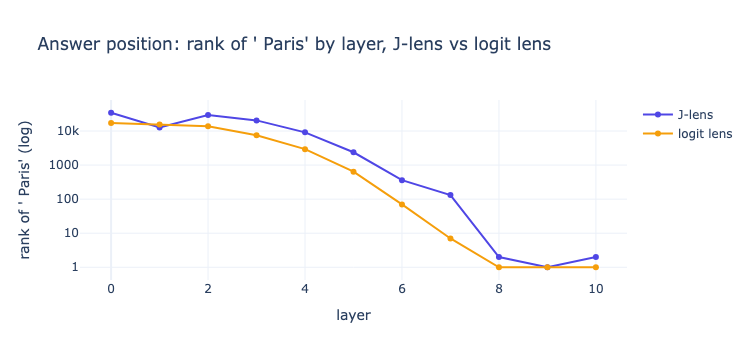

In [4]:
fig = go.Figure()
fig.add_scatter(x=LAYERS, y=[rank(jl[L][1], PARIS) for L in LAYERS], name="J-lens", mode="lines+markers", marker_color="#4f46e5")
fig.add_scatter(x=LAYERS, y=[rank(ll[L][1], PARIS) for L in LAYERS], name="logit lens", mode="lines+markers", marker_color="#f59e0b")
fig.update_yaxes(type="log", title="rank of ' Paris' (log)"); fig.update_xaxes(title="layer")
fig.update_layout(width=750, height=360, title="Answer position: rank of ' Paris' by layer, J-lens vs logit lens"); fig.show()

Layers 0–5 of the J-lens are noise (`ModLoader`, `ingred`, `senal`: the residue of averaging Jacobians over a small corpus at depths where nothing is verbalizable yet). This is the paper's "sensory" band, and on a 12-layer model it is half the network. Then, at **layer 6**, the J-lens reads *Canberra, Lexington, Constantinople*: not the answer, but its *type*. The model's residual stream at that point is disposed to make it say "some capital city", a full two layers before the logit lens shows any city at all (layer 7: Rome, Berlin, London) and two layers before either lens shows Paris (layer 8). By layer 9 both lenses agree, and by layer 10 the J-lens is the logit lens (Marseille, Paris, Lyon), the "motor" regime where $J_\ell \approx I$.

So on the answer position the J-lens buys exactly what the paper claims: an earlier, more abstract reading of the same computation the logit lens reads late. Notebook 3 found the hand-off into this position at layers 9–10 by patching; the lens sees the *slot being prepared* at layer 6 and *filled* at layer 8.

## 2. The country token: is the answer verbalizable at the source?

Now the question the circuit work makes sharp. Patching says the France-vs-Italy information sits at the `" France"` token through layer 8 and nowhere else. The logit lens at that token can only say what comes *next* (`" is"`, `"'s"`, `","`). The J-lens averages over future target positions too, so it should say what that token is disposed to make the model say *anywhere later*, which is where " Paris" would show up.

In [5]:
rows = []
for L in LAYERS:
    rows.append(dict(layer=L, jlens_country_pos=topk_str(jl[L][0], 6), paris_rank_jlens=rank(jl[L][0], PARIS),
                     logit_lens_country_pos=topk_str(ll[L][0], 6), paris_rank_logit_lens=rank(ll[L][0], PARIS)))
pd.DataFrame(rows)

,layer,jlens_country_pos,paris_rank_jlens,logit_lens_country_pos,paris_rank_logit_lens
0,0,"[France, France, French, French, Marse, Paris]",7,"[ Marse, France, Connection, Alps, and, press]",61
1,1,"[France, France, French, French, Hollande, Marse]",8,"[ Press, Connection, France, Marse, Media, Col]",103
2,2,"[France, France, French, French, François, Marse]",8,"[ Connection, Press, and, Media, Pres, Boss]",561
3,3,"[ France, France, French, French, french, Franco]",9,"[ and, Press, Riv, Pres, is, has]",402
4,4,"[France, France, French, French, François, Hollande]",9,"[ and, is, Press, has, Alps, border]",709
5,5,"[ France, France, French, French, Paris, François]",5,"[ and, is, has, Press, meanwhile, or]",493
6,6,"[France, France, Hollande, French, French, François]",8,"[ and, is, has, or, Pres, may]",303
7,7,"[ France, France, Hollande, French, François, Algeria]",7,"[ is, and, has, was, or, ville]",313
8,8,"[France, France, Hollande, French, François, bourg]",10,"[ is, and, has, was, are, consists]",151
9,9,"[France, France, bourg, Hollande, is, Lyon]",21,"[ is, has, and, consists, was, belongs]",237


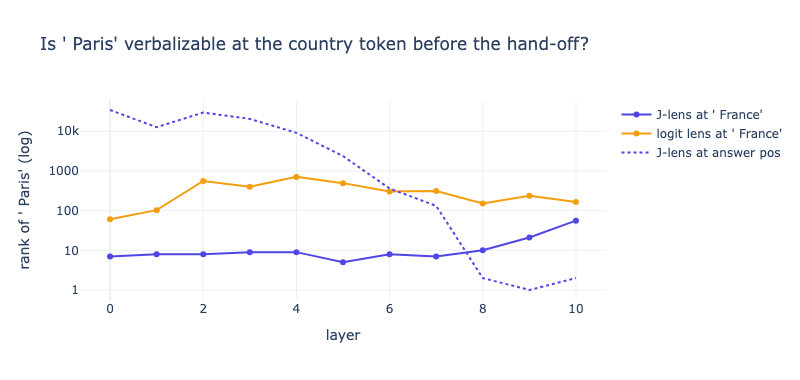

In [6]:
fig = go.Figure()
fig.add_scatter(x=LAYERS, y=[rank(jl[L][0], PARIS) for L in LAYERS], name="J-lens at ' France'", mode="lines+markers", marker_color="#4f46e5")
fig.add_scatter(x=LAYERS, y=[rank(ll[L][0], PARIS) for L in LAYERS], name="logit lens at ' France'", mode="lines+markers", marker_color="#f59e0b")
fig.add_scatter(x=LAYERS, y=[rank(jl[L][1], PARIS) for L in LAYERS], name="J-lens at answer pos", mode="lines", line=dict(dash="dot", color="#4f46e5"))
fig.update_yaxes(type="log", title="rank of ' Paris' (log)"); fig.update_xaxes(title="layer")
fig.update_layout(width=800, height=380, title="Is ' Paris' verbalizable at the country token before the hand-off?"); fig.show()

In [7]:
# Ten countries: rank of the capital at the COUNTRY token, J-lens vs logit lens, at layers 4 and 8
cases = [("France", " Paris"), ("Germany", " Berlin"), ("Japan", " Tokyo"), ("Italy", " Rome"), ("Spain", " Madrid"),
         ("China", " Beijing"), ("Egypt", " Cairo"), ("Russia", " Moscow"), ("Australia", " Canberra"), ("Canada", " Ottawa")]
rows = []
for country, capital in cases:
    demo = ("Germany", " Berlin") if country != "Germany" else ("France", " Paris")
    p = f"The capital of {demo[0]} is{demo[1]}. The capital of {country} is"
    cid = tid(capital)
    j, m, _ = readouts(p, [-2, -1], True); l, _, _ = readouts(p, [-2, -1], False)
    rows.append(dict(country=country, capital=capital.strip(),
                     jlens_L4=rank(j[4][0], cid), logit_lens_L4=rank(l[4][0], cid),
                     jlens_L8=rank(j[8][0], cid), logit_lens_L8=rank(l[8][0], cid),
                     jlens_L8_top=topk_str(j[8][0], 4), model_rank=rank(m[1], cid)))
df = pd.DataFrame(rows); df

,country,capital,jlens_L4,logit_lens_L4,jlens_L8,logit_lens_L8,jlens_L8_top,model_rank
0,France,Paris,9,709,10,151,"[France, France, Hollande, French]",1
1,Germany,Berlin,8,434,11,534,"[ Germany, Merkel, Germans, Dortmund]",1
2,Japan,Tokyo,6,2994,6,917,"[ Japan, Japan, Osaka, Okinawa]",1
3,Italy,Rome,9,500,8,53,"[ Italy, Italians, Italy, Naples]",1
4,Spain,Madrid,7,184,4,43,"[Spain, Spain, Catalonia, Madrid]",1
5,China,Beijing,5,79,2,23,"[ China, Beijing, China, Shanghai]",1
6,Egypt,Cairo,5,99,4,270,"[Egypt, Egyptians, Egypt, Cairo]",1
7,Russia,Moscow,3,317,1,186,"[ Moscow, Russia, Putin, Vlad]",1
8,Australia,Canberra,7,1217,3,448,"[ Australia, Australia, Canberra, Australians]",3
9,Canada,Ottawa,9,1162,6,428,"[Canada, Canada, Canadians, Canadian]",3


In [8]:
print(f"median rank of the capital at the country token, layer 8: J-lens {df.jlens_L8.median():.0f}, logit lens {df.logit_lens_L8.median():.0f}")
print(f"countries with capital in J-lens top-10 at the country token (L8): {(df.jlens_L8 <= 10).sum()}/10; logit lens: {(df.logit_lens_L8 <= 10).sum()}/10")

median rank of the capital at the country token, layer 8: J-lens 5, logit lens 228
countries with capital in J-lens top-10 at the country token (L8): 9/10; logit lens: 0/10


It does, and more strongly than expected. At the `" France"` token the J-lens reads *France, French, Hollande, Marseille, François* at every layer from 0 to 9, with **" Paris" in the top 10 at every one of those layers** (ranks 5–10), while the logit lens has it at rank 61–709 and reads only `'s`, `,`, `and`, `is`. At layer 10 the J-lens flips to `is, occupies, comprises`: the motor regime again, now at a position whose next token really is " is".

Across ten countries the picture is the same: at layer 8 the capital is in the J-lens top 10 for **9 of 10** (median rank 5; Moscow is rank 1 for Russia, Beijing rank 2 for China) and in the logit lens top 10 for **0 of 10** (median rank 228). Compare this list to notebook 2, where L9H8's OV circuit applied to the `" France"` residual produced *French, Hollande, Marseille, Paris, Macron*: the J-lens at the country token is reading out, averaged over contexts, the same thing the circuit's copy head reads out on this prompt. That is not a coincidence. $J_\ell$ at the country position *includes* the paths through L8H11, L9H8 and L10H0 to later positions, because those heads attend to whatever sits in the country slot on most prompts of this shape. The J-lens is the circuit's broadcast, seen from the source.

Two honest qualifications.

- **Layer 0 already shows it.** At layer 0 the residual stream is just the embedding of `" France"` plus a position; nothing has been computed. That " Paris" is rank 7 there means $J_0$ carries the model's *general disposition* to say Paris after seeing France, baked into the weights, not any context-specific processing. The paper is explicit that early-layer readouts are not workspace content, and the answer-position results (Section 1) show why: where context has to be *integrated*, the early layers read as noise. The country token is the easy case, a single proper noun whose downstream effects are stereotyped.
- **This is availability, not use.** Notebook 3 established that the model does not *act* on this information until layers 8–10. The J-lens says the fact is verbalizable at the source from the start; patching says it is collected late. Both are true, and the gap between them is the difference between "poised to say" and "said".

## 3. Does GPT-2 Small have the paper's layer structure?

The paper (Fig. 28) identifies a workspace band in Sonnet 4.5 with four lens-derived statistics, computed over ordinary text: (a) how often the J-lens top-10 contains the model's actual next token, near zero early and rising steeply only in the last layers; (b) excess kurtosis of the readout distribution, which rises at the workspace onset; (c) autocorrelation of the top-1 lens token across nearby positions relative to a shuffled null, high only in the workspace band; (d) the effective dimensionality of the J-lens vectors $W_U J_\ell$, which fans out at the onset. Here are the same four on 30 held-out WikiText prompts.

In [9]:
from jlens.examples import load_wikitext_prompts
heldout = load_wikitext_prompts(130)[100:]      # the first 100 were used to fit the lens
print(len(heldout), "held-out prompts")

W_U = hf.lm_head.weight.detach().float().cpu()  # [vocab, d_model]
sig = {L: dict(top1_match=[], kurt=[], top1=[]) for L in LAYERS}
for p in heldout:
    jl_all, m_all, ids_ = lens.apply(model, p, positions=None, max_seq_len=128)
    n = m_all.shape[0]; valid = range(16, n - 1)
    model_top1 = m_all.argmax(-1)
    for L in LAYERS:
        lg = jl_all[L]
        top = lg.topk(10, dim=-1).indices
        sig[L]["top1_match"] += [(top[t] == model_top1[t]).any().item() for t in valid]
        sig[L]["kurt"] += [stats.kurtosis(lg[t].numpy()) for t in valid]
        sig[L]["top1"].append(lg[list(valid)].argmax(-1))

def autocorr(top1_list, delta=4):
    same, null = [], []
    for s in top1_list:
        if len(s) <= delta: continue
        same.append((s[:-delta] == s[delta:]).float().mean().item())
        perm = s[torch.randperm(len(s))]
        null.append((perm[:-delta] == perm[delta:]).float().mean().item())
    return np.mean(same), np.mean(null)

rows = []
for L in LAYERS:
    ac, ac_null = autocorr(sig[L]["top1"])
    M = W_U @ lens.jacobians[L].float().cpu()               # J-lens vectors, [vocab, d_model]
    M = M - M.mean(0, keepdim=True)
    sv = torch.linalg.svdvals(M[torch.randperm(M.shape[0])[:8000]])
    frac = ((sv**2).cumsum(0) / (sv**2).sum() < 0.9).sum().item() / M.shape[1]
    rows.append(dict(layer=L, top10_contains_model_top1=round(np.mean(sig[L]["top1_match"]), 3),
                     excess_kurtosis=round(float(np.median(sig[L]["kurt"])), 1),
                     top1_autocorr=round(ac, 3), autocorr_null=round(ac_null, 3),
                     dims_for_90pct_var=round(frac, 2)))
sigdf = pd.DataFrame(rows); sigdf

30 held-out prompts


,layer,top10_contains_model_top1,excess_kurtosis,top1_autocorr,autocorr_null,dims_for_90pct_var
0,0,0.003,0.3,0.052,0.061,0.12
1,1,0.005,0.5,0.073,0.065,0.16
2,2,0.006,0.5,0.030,0.032,0.19
3,3,0.009,0.3,0.019,0.019,0.21
4,4,0.008,0.3,0.019,0.018,0.22
5,5,0.021,0.3,0.018,0.019,0.23
6,6,0.035,0.3,0.016,0.014,0.27
7,7,0.099,0.3,0.009,0.008,0.32
8,8,0.138,0.4,0.022,0.018,0.37
9,9,0.285,0.5,0.026,0.017,0.46


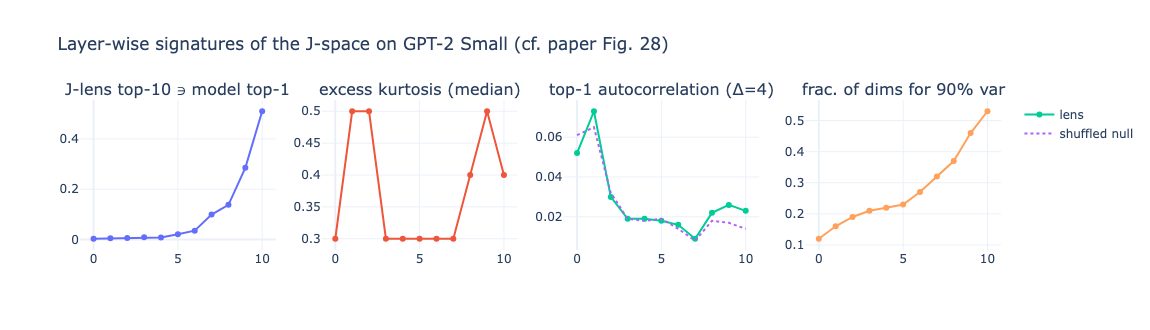

In [10]:
fig = make_subplots(rows=1, cols=4, subplot_titles=["J-lens top-10 ∋ model top-1", "excess kurtosis (median)", "top-1 autocorrelation (Δ=4)", "frac. of dims for 90% var"])
fig.add_scatter(x=sigdf.layer, y=sigdf.top10_contains_model_top1, mode="lines+markers", showlegend=False, row=1, col=1)
fig.add_scatter(x=sigdf.layer, y=sigdf.excess_kurtosis, mode="lines+markers", showlegend=False, row=1, col=2)
fig.add_scatter(x=sigdf.layer, y=sigdf.top1_autocorr, mode="lines+markers", name="lens", row=1, col=3)
fig.add_scatter(x=sigdf.layer, y=sigdf.autocorr_null, mode="lines", line=dict(dash="dot"), name="shuffled null", row=1, col=3)
fig.add_scatter(x=sigdf.layer, y=sigdf.dims_for_90pct_var, mode="lines+markers", showlegend=False, row=1, col=4)
fig.update_layout(width=1150, height=330, title="Layer-wise signatures of the J-space on GPT-2 Small (cf. paper Fig. 28)"); fig.show()

No band. All four curves are monotone or flat: next-token agreement climbs smoothly from 0 to 51% at layer 10 with no plateau; median excess kurtosis sits at 0.3–0.5 in every layer (Sonnet's rises by orders of magnitude at the workspace onset); top-1 autocorrelation is *at the shuffled null in every layer*, meaning the top lens token at position $t$ says nothing about the top token at $t+4$; and the J-lens vectors' dimensionality grows steadily from 12% to 53% of the residual stream rather than fanning out at a particular depth. On the paper's own criteria, GPT-2 Small has a sensory band that runs into a motor ramp with nothing in between.

That is a real negative result, with two readings. The modest one: 124M parameters and 12 layers are simply too small for a workspace to be worth having, so it does not emerge, which would make the workspace a scale (or recipe) phenomenon like the head concentration in notebook 5. The cautious one: the lens was fitted on 100 prompts instead of 1000, on the final rather than penultimate layer, and the signatures are measured on prose where GPT-2 Small's top-1 readouts are often junk tokens (`ModLoader`, `occas`); a better fit or a junk-filtered autocorrelation might recover a weak band. Sections 1 and 2 show the lens is not *broken* on this model, so the absence of prose-level persistence is at least partly about the model.

## 4. The list experiment, in miniature

One of the paper's more vivid results (its Fig. 31): when the model reads a comma-separated list, the J-space fills with the list's *category*, including members that have not been read, and a category switch evicts the old members within a word or two. That is a structured context where persistence should be visible even if it is not in prose. Read the layer-6 J-lens at each comma.

In [11]:
animals = "shark, whale, eagle, tiger, salmon, sparrow, cobra, otter"
colors = "red, blue, green, yellow, purple, orange, pink, brown"
def list_readout(text, layer=6, k=12):
    ids_ = model.encode(text)[0]; toks = [tok.decode(i) for i in ids_]
    commas = [i for i, t in enumerate(toks) if t == ","]
    j, _, _ = lens.apply(model, text, positions=commas, layers=[layer])
    words = [w.strip() for w in text.split(",") if w.strip()]
    return [(words[n], topk_str(j[layer][n], k)) for n, c in enumerate(commas)]
for word, top in list_readout(animals + ","):
    print(f"after {word!r:10s}: {top}")

after 'shark'   : [' laun', ' encount', ' occas', 'ModLoader', ' gobl', 'ccording', ' kittens', ' tiss', ' rul', ' cryst', ' rabbits', ' rook']
after 'whale'   : ['ModLoader', ' whales', ' whale', ' nep', ' etc', ' occas', ' kittens', ' mammal', ' rabbit', ' dolphin', ' gobl', ' rabbits']
after 'eagle'   : ['ModLoader', ' occas', ' etc', ' totem', ' gobl', ' helicop', ' enthusi', ' whales', ' thous', ' nodd', ' tyr', ' surv']
after 'tiger'   : ['ModLoader', ' occas', ' etc', ' tyr', ' totem', ' whales', ' helicop', ' gobl', ' rabbits', ' enthusi', ' thous', ' whale']
after 'salmon'  : ['ModLoader', ' salmon', ' whales', ' occas', ' trout', ' wool', ' rabbits', ' etc', ' gobl', ' whale', ' chickens', ' rabbit']
after 'sparrow' : [' etc', ' occas', 'ModLoader', ' rabbits', ' wool', ' whales', ' poultry', ' trout', ' rabbit', ' bird', ' hog', ' turtle']
after 'cobra'   : [' rabbits', 'ModLoader', ' gobl', ' occas', ' etc', ' bird', ' wool', ' turtle', ' rabbit', ' butterflies', ' chickens

In [12]:
print("category switch: eight animals then colors")
for word, top in list_readout(animals + ", " + colors + ","):
    print(f"after {word!r:10s}: {top}")

category switch: eight animals then colors
after 'shark'   : [' laun', ' encount', ' occas', 'ModLoader', ' gobl', 'ccording', ' kittens', ' tiss', ' rul', ' cryst', ' rabbits', ' rook']
after 'whale'   : ['ModLoader', ' whales', ' whale', ' nep', ' etc', ' occas', ' kittens', ' mammal', ' rabbit', ' dolphin', ' gobl', ' rabbits']
after 'eagle'   : ['ModLoader', ' occas', ' etc', ' totem', ' gobl', ' helicop', ' enthusi', ' whales', ' thous', ' nodd', ' tyr', ' surv']
after 'tiger'   : ['ModLoader', ' occas', ' etc', ' tyr', ' totem', ' whales', ' helicop', ' gobl', ' rabbits', ' enthusi', ' thous', ' whale']
after 'salmon'  : ['ModLoader', ' salmon', ' whales', ' occas', ' trout', ' wool', ' rabbits', ' etc', ' gobl', ' whale', ' chickens', ' rabbit']
after 'sparrow' : [' etc', ' occas', 'ModLoader', ' rabbits', ' wool', ' whales', ' poultry', ' trout', ' rabbit', ' bird', ' hog', ' turtle']
after 'cobra'   : [' rabbits', 'ModLoader', ' gobl', ' occas', ' etc', ' bird', ' wool', ' tur

Ignore the junk tokens (`ModLoader`, `occas`, `etc`, `brill` survive the filter; they are averaging artifacts of the small fit) and read the rest. After "whale": *whales, kittens, mammal, rabbit, dolphin*. After "salmon": *trout, wool, chickens, rabbit*. After "otter": *totem, rabbit, bird, mammal, whales, deer, hog, turtle*. Almost none of these appear in the list. The J-space is holding "animals", and specifically a farm-and-wildlife neighborhood of animals, not the eight words read. Then "red" arrives and within one token the readout is *gray, brown, colors*; by "blue" it is *colors, violet, gray, blue, purple, colours* and the animals are gone except a lingering *rabbit* and *wool*. The paper's category loading and category eviction, on a model a thousand times smaller, at layer 6 of 12.

This is also the persistence Section 3 could not see in prose: in a context that *has* a category, the J-space at layer 6 carries it across positions. The autocorrelation statistic averaged over WikiText simply has too few such contexts to register it.

## 5. What we learned

- **The J-lens works on GPT-2 Small** in the sense that matters: at the answer position it reads the *type* of the answer two layers before the logit lens reads any answer, and at the source token it reads the fact the circuit will later copy, with the capital in the top 10 for 9 of 10 countries where the logit lens has it at rank ~200.
- **The J-lens readout at the source is the circuit's broadcast, seen from the other end.** Its top tokens at `" France"` are the same tokens L9H8's OV matrix produces (notebook 2), because $J_\ell$ averages over exactly the paths those heads implement. Lenses and circuits are two views of one object; here they agree to the token.
- **Availability precedes use.** The fact is verbalizable at the country token from layer 0 (partly a property of the embedding, not of computation) and is acted on at layers 8–10. Keep the two ideas separate.
- **GPT-2 Small has no workspace band by the paper's four signatures**, though it does show category loading and eviction in lists at layer 6. Whether the band appears with scale, with recipe, or only with post-training (the paper's Assistant-perspective results suggest post-training matters a lot) is the natural next sweep, and `jlens.fit` on Qwen3-1.7B costs about five minutes per prompt on this machine, so an overnight 100-prompt fit is feasible.

**Caveats.** One lens fit (100 prompts, final-layer target, mean aggregation); the paper reports its results are fairly robust to these choices but on a much larger model. Ranks are over the full 50k vocabulary with no filtering; top-k lists use the paper's junk filter. Everything about "the workspace" here is the paper's operationalization applied to a model it was not designed for.

In [13]:
# PLAYGROUND
# - lens.apply(model, "Fact: The currency used in the country shaped like a boot is", positions=[-2, -1])
#   Does the J-space at ' boot' contain ' Italy' or ' lira'/' euro' before the answer position does?
# - Re-fit with target_layer=-2 (penultimate), the paper's default for Sonnet, and compare Section 3.
# - jlens.vis.build_page renders the paper's interactive layer × position viewer for any prompt.